<a href="https://colab.research.google.com/github/GinnaGomez09/proyecto_aplicado_javeriana/blob/main/notebooks/01_eda_recetas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 01_EDA_RECETAS.ipynb
# Análisis Exploratorio de Datos - Recetas + TCAC
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Mostrar más columnas y texto
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# ------------------------------------------------------------
# 1. Clonar repositorio y entrar a la carpeta
# ------------------------------------------------------------

!git clone https://github.com/GinnaGomez09/proyecto_aplicado_javeriana.git

%cd proyecto_aplicado_javeriana

# ------------------------------------------------------------
# 2. Cargar datasets
# ------------------------------------------------------------

recetas_path = "data/raw/recetas/recetas_ingredientes.csv"
tcac_path = "data/raw/tcac/tcac.csv"

recetas = pd.read_csv(recetas_path)
tcac = pd.read_csv(tcac_path)

print("Dataset recetas:", recetas.shape)
print("Dataset TCAC:", tcac.shape)

Cloning into 'proyecto_aplicado_javeriana'...
remote: Enumerating objects: 246, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 246 (delta 72), reused 18 (delta 18), pack-reused 142 (from 1)
Receiving objects: 100% (246/246), 3.18 MiB | 4.29 MiB/s, done.
Resolving deltas: 100% (126/126), done.
/content/proyecto_aplicado_javeriana/proyecto_aplicado_javeriana/proyecto_aplicado_javeriana/proyecto_aplicado_javeriana
Dataset recetas: (31587, 16)
Dataset TCAC: (773, 41)


In [ ]:
# ------------------------------------------------------------
# 3. Vista inicial de recetas
# ------------------------------------------------------------

recetas.head()

,receta_uuid,receta_titulo,receta_url,ingrediente_id,ingrediente_linea,cantidad_original,cantidad_conv,cantidad_min,cantidad_max,unidad,ingrediente_nombre,tcac_alimento_codigo,tcac_alimento_nombre,match_method,match_score,cantidad_gramos_est
0,86af61e4-e16a-11ed-9591-a96d6180cd25,Arepas de Queso,https://www.mycolombianrecipes.com/es/arepas-de-queso/,1,1 taza de harina de arepa blanca o amarilla,1,1.000000,NaN,NaN,taza,harina de arepa blanca o amarilla,NaN,NaN,NaN,NaN,NaN
1,86af61e4-e16a-11ed-9591-a96d6180cd25,Arepas de Queso,https://www.mycolombianrecipes.com/es/arepas-de-queso/,2,1 taza de agua tibia,1,1.000000,NaN,NaN,taza,agua tibia,NaN,NaN,NaN,NaN,NaN
2,86af61e4-e16a-11ed-9591-a96d6180cd25,Arepas de Queso,https://www.mycolombianrecipes.com/es/arepas-de-queso/,3,⅓ taza de queso mozzarella o queso blanco rallado,⅓,0.333333,NaN,NaN,taza,queso mozzarella o queso blanco rallado,NaN,NaN,NaN,NaN,NaN
3,86af61e4-e16a-11ed-9591-a96d6180cd25,Arepas de Queso,https://www.mycolombianrecipes.com/es/arepas-de-queso/,4,2 cucharadas de mantequilla,2,2.000000,NaN,NaN,cucharadas,mantequilla,NaN,NaN,NaN,NaN,NaN
4,86af61e4-e16a-11ed-9591-a96d6180cd25,Arepas de Queso,https://www.mycolombianrecipes.com/es/arepas-de-queso/,5,Sal,NaN,NaN,NaN,NaN,NaN,Sal,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ------------------------------------------------------------
# 4. Vista inicial de TCAC
# ------------------------------------------------------------

tcac.head()

,grupo_Alimento,codigo,nombre_alimento,parte_analizada,humedad_g,energia_kcal,energia_kj,proteina_g,lipidos_g,carbohidratos_totales_g,carbohidratos_disponibles_g,fibra_dietaria_g,cenizas_g,calcio_mg,hierro_mg,sodio_mg,fosforo_mg,yodo_mg,zinc_mg,magnesio_mg,potasio_mg,tiamina_mg,riboflavina_mg,niacina_mg,Folatos (mcg),vitamina_b12_mcg,vitamina_c_mg,vitamina_a_er,grasa_saturada_g,grasa_monoinsaturada_g,grasa_poliinsaturada_g,colesterol_mg,parte_comestible_pct,puntaje_positivo,puntaje_negativo,carga_nutricional_nrf,ratio_carbo_fibra,calidad_carbo_fibra,ratio_grasas_saludables,calidad_grasa,Energía (kcal)
0,Cereales_Derivados,A001,"Almidón de maíz, crudo",NaN,8.0,370.0,1571,0.3,0.1,91.4,90.5,0.9,0.1,2.0,0.5,9.0,14.0,0.5,0.1,3.0,3.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,7.524025,0.0,7.524025,101.555556,Baja (Refinado),0.0,Baja (Proaterogénica),NaN
1,Cereales_Derivados,A002,"Almojábana, bogotana, horneada",NaN,41.3,285.0,1196,13.0,12.3,30.6,NaN,NaN,2.8,320.0,2.2,NaN,330.0,NaN,NaN,NaN,NaN,0.08,0.40,0.9,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,100.0,62.837607,0.0,62.837607,NaN,Baja (Sin Fibra),NaN,NaN,NaN
2,Cereales_Derivados,A003,"Almojábana, vallecaucana, horneada",NaN,29.1,341.0,1430,17.5,14.7,34.6,NaN,NaN,4.1,500.0,2.2,NaN,340.0,NaN,NaN,NaN,NaN,0.04,0.40,0.1,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,100.0,85.683761,0.0,85.683761,NaN,Baja (Sin Fibra),NaN,NaN,NaN
3,Cereales_Derivados,A004,"Arepa de maíz precocido, con sal",NaN,60.3,163.0,690,3.3,0.9,35.0,34.1,0.9,0.6,17.0,0.7,188.0,22.0,NaN,0.2,10.0,55.0,0.09,0.09,0.1,NaN,NaN,0.0,36.0,NaN,NaN,NaN,NaN,100.0,22.562032,0.0,22.562032,38.888889,Baja (Refinado),NaN,NaN,NaN
4,Cereales_Derivados,A005,"Arepa de maíz precocido, sin sal",NaN,61.3,156.0,664,3.4,0.5,34.5,NaN,NaN,0.3,19.0,0.5,NaN,163.0,NaN,0.2,10.0,33.0,0.36,0.05,1.4,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,100.0,14.122396,0.0,14.122396,NaN,Baja (Sin Fibra),NaN,NaN,NaN


In [ ]:
# ------------------------------------------------------------
# 6. Información general
# ------------------------------------------------------------

print("INFO RECETAS")
recetas.info()

print("\nINFO TCAC")
tcac.info()

INFO RECETAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31587 entries, 0 to 31586
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   receta_uuid           30301 non-null  object 
 1   receta_titulo         25990 non-null  object 
 2   receta_url            31587 non-null  object 
 3   ingrediente_id        31587 non-null  int64  
 4   ingrediente_linea     31587 non-null  object 
 5   cantidad_original     27049 non-null  object 
 6   cantidad_conv         26995 non-null  float64
 7   cantidad_min          53 non-null     float64
 8   cantidad_max          54 non-null     float64
 9   unidad                18097 non-null  object 
 10  ingrediente_nombre    31587 non-null  object 
 11  tcac_alimento_codigo  0 non-null      float64
 12  tcac_alimento_nombre  0 non-null      float64
 13  match_method          0 non-null      float64
 14  match_score           0 non-null      float64
 15  cantid

In [ ]:
# ------------------------------------------------------------
# 7. Valores nulos
# ------------------------------------------------------------

nulos_recetas = recetas.isnull().sum().sort_values(ascending=False)
nulos_tcac = tcac.isnull().sum().sort_values(ascending=False)

print("Nulos recetas:")
display(nulos_recetas[nulos_recetas > 0])

print("\nNulos TCAC:")
display(nulos_tcac[nulos_tcac > 0])

Nulos recetas:


,0
tcac_alimento_nombre,31587
match_method,31587
match_score,31587
cantidad_gramos_est,31587
tcac_alimento_codigo,31587
cantidad_min,31534
cantidad_max,31533
unidad,13490
receta_titulo,5597
cantidad_conv,4592



Nulos TCAC:


,0
ratio_carbo_fibra,707
calidad_carbo_fibra,684
energia_kcal,684
colesterol_mg,481
calidad_grasa,469
grasa_poliinsaturada_g,469
ratio_grasas_saludables,469
grasa_monoinsaturada_g,469
grasa_saturada_g,469
yodo_mg,441


In [ ]:
# ------------------------------------------------------------
# 8. Duplicados
# ------------------------------------------------------------

print("Duplicados completos en recetas:", recetas.duplicated().sum())
print("Duplicados completos en TCAC:", tcac.duplicated().sum())

Duplicados completos en recetas: 769
Duplicados completos en TCAC: 0


In [ ]:
# ------------------------------------------------------------
# 10. Frecuencia de ingredientes
# ------------------------------------------------------------

if col_ingrediente:
    top_ingredientes = recetas[col_ingrediente].astype(str).str.strip().value_counts().head(25)
    display(top_ingredientes)
else:
    print("No se detectó columna de ingrediente. Revisa nombres de columnas.")

,count
ingrediente_nombre,
azúcar,102
agua,101
comino molido,91
Sal y pimienta al gusto,69
Sal y pimienta,62
sal,61
mantequilla,60
ajo picados,47
extracto de vainilla,46


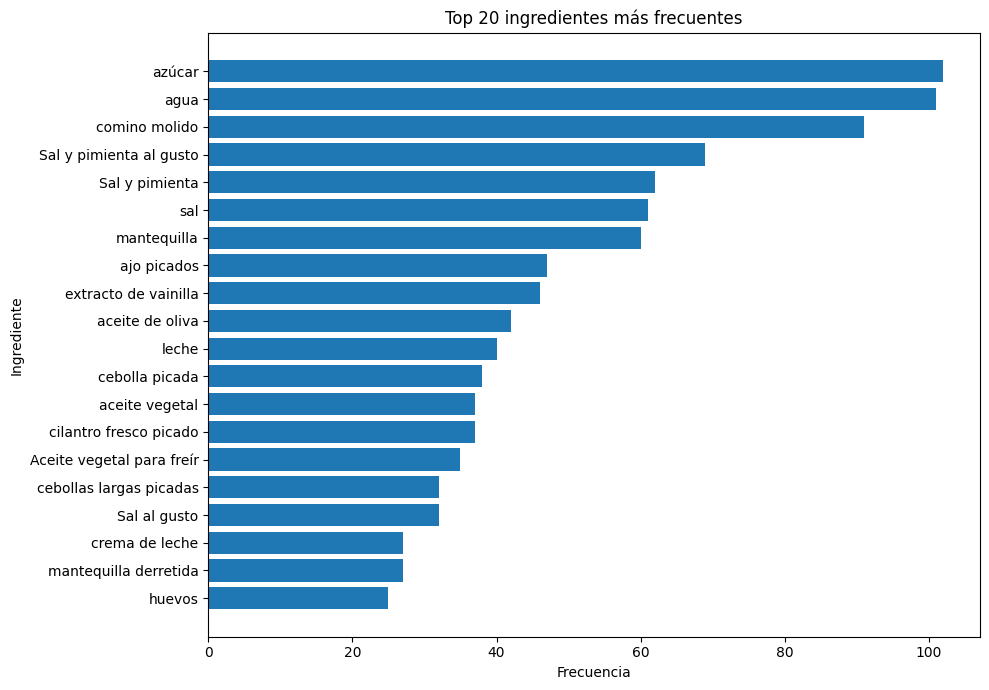

In [ ]:
# ------------------------------------------------------------
# 11. Gráfico top ingredientes
# ------------------------------------------------------------

if col_ingrediente:
    top_ingredientes = recetas[col_ingrediente].astype(str).str.strip().value_counts().head(20)

    plt.figure(figsize=(10, 7))
    plt.barh(top_ingredientes.index[::-1], top_ingredientes.values[::-1])
    plt.title("Top 20 ingredientes más frecuentes")
    plt.xlabel("Frecuencia")
    plt.ylabel("Ingrediente")
    plt.tight_layout()
    plt.show()

,count
unidad,
nan,13490
gramos,4766
gr.,1620
taza,1534
unidades,1065
tazas,945
kilogramo,911
cucharadas,691
unidad,633


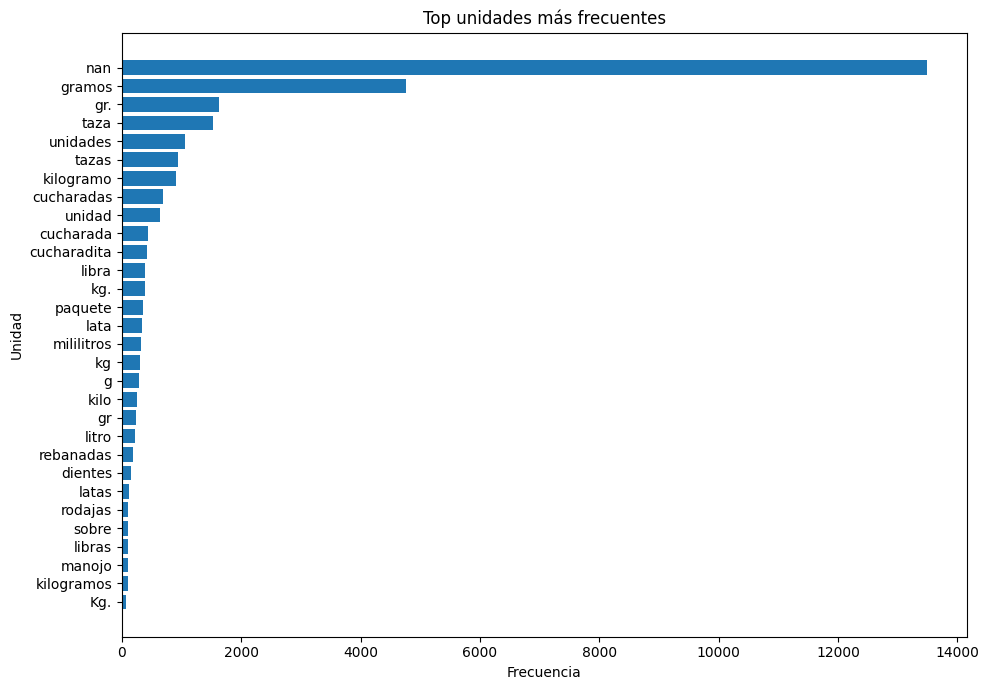

In [ ]:
# ------------------------------------------------------------
# 12. Análisis de unidades
# ------------------------------------------------------------

if col_unidad:
    top_unidades = recetas[col_unidad].astype(str).str.strip().value_counts().head(30)
    display(top_unidades)

    plt.figure(figsize=(10, 7))
    plt.barh(top_unidades.index[::-1], top_unidades.values[::-1])
    plt.title("Top unidades más frecuentes")
    plt.xlabel("Frecuencia")
    plt.ylabel("Unidad")
    plt.tight_layout()
    plt.show()
else:
    print("No se detectó columna de unidad.")

In [ ]:
# ------------------------------------------------------------
# 13. Análisis de cantidades
# ------------------------------------------------------------

if col_cantidad:
    display(recetas[col_cantidad].describe(include="all"))

    print("Ejemplos de cantidades:")
    display(recetas[[col_cantidad]].dropna().head(20))
else:
    print("No se detectó columna de cantidad.")

,cantidad_original
count,27049
unique,224
top,1
freq,7880


Ejemplos de cantidades:


,cantidad_original
0,1
1,1
2,⅓
3,2
5,8
6,1
7,½
8,½
9,1
10,2


,longitud_ingrediente
count,31587.000000
mean,189.837306
std,126.623313
min,3.000000
25%,106.000000
50%,175.000000
75%,252.000000
max,1229.000000


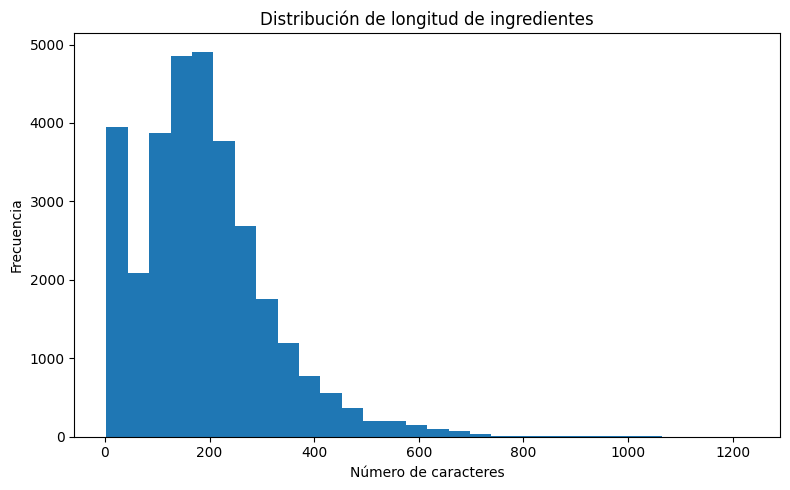

In [ ]:
# ------------------------------------------------------------
# 14. Longitud textual de ingredientes
# ------------------------------------------------------------

if col_ingrediente:
    recetas["longitud_ingrediente"] = recetas[col_ingrediente].astype(str).apply(len)

    display(recetas["longitud_ingrediente"].describe())

    plt.figure(figsize=(8, 5))
    plt.hist(recetas["longitud_ingrediente"], bins=30)
    plt.title("Distribución de longitud de ingredientes")
    plt.xlabel("Número de caracteres")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

In [ ]:
# ------------------------------------------------------------
# 15. Problemas de texto: números en ingredientes
# ------------------------------------------------------------

if col_ingrediente:
    ingredientes_con_numeros = recetas[
        recetas[col_ingrediente].astype(str).str.contains(r"\d", regex=True, na=False)
    ]

    print("Ingredientes con números:", ingredientes_con_numeros.shape[0])
    display(ingredientes_con_numeros.head(20))

Ingredientes con números: 27028


,receta_uuid,receta_titulo,receta_url,ingrediente_id,ingrediente_linea,cantidad_original,cantidad_conv,cantidad_min,cantidad_max,unidad,ingrediente_nombre,tcac_alimento_codigo,tcac_alimento_nombre,match_method,match_score,cantidad_gramos_est,longitud_ingrediente
23,86af61e6-e16a-11ed-bcf5-a96d6180cd25,Sancocho Trifásico,https://www.mycolombianrecipes.com/es/sancocho-trifasico/,6,3 mazorcas de maíz cortado en 3 piezas,3,3.0,NaN,NaN,NaN,mazorcas de maíz cortado en 3 piezas,NaN,NaN,NaN,NaN,NaN,36
28,86af61e6-e16a-11ed-bcf5-a96d6180cd25,Sancocho Trifásico,https://www.mycolombianrecipes.com/es/sancocho-trifasico/,11,2 plátanos verdes pelados y cortados transversalmente en pedazos de 2 pulgadas,2,2.0,NaN,NaN,NaN,plátanos verdes pelados y cortados transversalmente en pedazos de 2 pulgadas,NaN,NaN,NaN,NaN,NaN,76
34,86af61e7-e16a-11ed-8914-a96d6180cd25,Sudado de Posta o Muchacho,https://www.mycolombianrecipes.com/es/sudado-de-posta-o-muchacho/,1,"1 posta o muchacho de 3 a 4 libras, cortada en rodajas gruesas",1,1.0,NaN,NaN,NaN,"posta o muchacho de 3 a 4 libras, cortada en rodajas gruesas",NaN,NaN,NaN,NaN,NaN,60
67,86af71be-e16a-11ed-afa4-a96d6180cd25,Bistec a la Criolla,https://www.mycolombianrecipes.com/es/bistec-a-la-criolla/,1,"2 libras de carne de bistec falda, cortado en 4 porciones iguales",2,2.0,NaN,NaN,libras,"carne de bistec falda, cortado en 4 porciones iguales",NaN,NaN,NaN,NaN,NaN,53
130,86af71c5-e16a-11ed-bdfb-a96d6180cd25,Capón Relleno,https://www.mycolombianrecipes.com/es/capon-relleno/,1,1 muchacho posta o capón de 3 a 4 libras entero,1,1.0,NaN,NaN,NaN,muchacho posta o capón de 3 a 4 libras entero,NaN,NaN,NaN,NaN,NaN,45
138,86af71c6-e16a-11ed-abc5-a96d6180cd25,Bistec a Caballo,https://www.mycolombianrecipes.com/es/bistec-a-caballo/,1,2 libra de bistec de falda y cortado en 4 porciones iguales,2,2.0,NaN,NaN,libra,bistec de falda y cortado en 4 porciones iguales,NaN,NaN,NaN,NaN,NaN,48
169,86af71c8-e16a-11ed-a535-a96d6180cd25,Cazuela de Mariscos Colombiana,https://www.mycolombianrecipes.com/es/cazuela-de-mariscos-colombiana/,11,"1 lata 13,5 oz de leche de coco",1,1.0,NaN,NaN,lata,"13,5 oz de leche de coco",NaN,NaN,NaN,NaN,NaN,24
177,86af71c9-e16a-11ed-bf34-a96d6180cd25,Arroz Atollado de Pollo y Chorizo,https://www.mycolombianrecipes.com/es/arroz-atollado-de-pollo-y-chorizo/,1,3 pechugas de pollo con hueso 8 y muslos de pollo o las piernas,3,3.0,NaN,NaN,NaN,pechugas de pollo con hueso 8 y muslos de pollo o las piernas,NaN,NaN,NaN,NaN,NaN,61
192,86af71c9-e16a-11ed-bf34-a96d6180cd25,Arroz Atollado de Pollo y Chorizo,https://www.mycolombianrecipes.com/es/arroz-atollado-de-pollo-y-chorizo/,16,2 tazas de papas peladas y cortadas en 1 y ½ pulgadas piezas,2,2.0,NaN,NaN,tazas,papas peladas y cortadas en 1 y ½ pulgadas piezas,NaN,NaN,NaN,NaN,NaN,49
233,86af71cd-e16a-11ed-b708-a96d6180cd25,Sopa de Arroz con Pollo,https://www.mycolombianrecipes.com/es/sopa-de-arroz-con-pollo/,1,8 muslos de pollo o 4 pechugas,8,8.0,NaN,NaN,NaN,muslos de pollo o 4 pechugas,NaN,NaN,NaN,NaN,NaN,28


In [ ]:
# ------------------------------------------------------------
# 16. Problemas de texto: caracteres especiales
# ------------------------------------------------------------

if col_ingrediente:
    patron_raro = r"[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ\s]"
    ingredientes_caracteres_raros = recetas[
        recetas[col_ingrediente].astype(str).str.contains(patron_raro, regex=True, na=False)
    ]

    print("Ingredientes con caracteres especiales:", ingredientes_caracteres_raros.shape[0])
    display(ingredientes_caracteres_raros.head(20))

Ingredientes con caracteres especiales: 27433


,receta_uuid,receta_titulo,receta_url,ingrediente_id,ingrediente_linea,cantidad_original,cantidad_conv,cantidad_min,cantidad_max,unidad,ingrediente_nombre,tcac_alimento_codigo,tcac_alimento_nombre,match_method,match_score,cantidad_gramos_est,longitud_ingrediente
23,86af61e6-e16a-11ed-bcf5-a96d6180cd25,Sancocho Trifásico,https://www.mycolombianrecipes.com/es/sancocho-trifasico/,6,3 mazorcas de maíz cortado en 3 piezas,3,3.0,NaN,NaN,NaN,mazorcas de maíz cortado en 3 piezas,NaN,NaN,NaN,NaN,NaN,36
28,86af61e6-e16a-11ed-bcf5-a96d6180cd25,Sancocho Trifásico,https://www.mycolombianrecipes.com/es/sancocho-trifasico/,11,2 plátanos verdes pelados y cortados transversalmente en pedazos de 2 pulgadas,2,2.0,NaN,NaN,NaN,plátanos verdes pelados y cortados transversalmente en pedazos de 2 pulgadas,NaN,NaN,NaN,NaN,NaN,76
34,86af61e7-e16a-11ed-8914-a96d6180cd25,Sudado de Posta o Muchacho,https://www.mycolombianrecipes.com/es/sudado-de-posta-o-muchacho/,1,"1 posta o muchacho de 3 a 4 libras, cortada en rodajas gruesas",1,1.0,NaN,NaN,NaN,"posta o muchacho de 3 a 4 libras, cortada en rodajas gruesas",NaN,NaN,NaN,NaN,NaN,60
67,86af71be-e16a-11ed-afa4-a96d6180cd25,Bistec a la Criolla,https://www.mycolombianrecipes.com/es/bistec-a-la-criolla/,1,"2 libras de carne de bistec falda, cortado en 4 porciones iguales",2,2.0,NaN,NaN,libras,"carne de bistec falda, cortado en 4 porciones iguales",NaN,NaN,NaN,NaN,NaN,53
130,86af71c5-e16a-11ed-bdfb-a96d6180cd25,Capón Relleno,https://www.mycolombianrecipes.com/es/capon-relleno/,1,1 muchacho posta o capón de 3 a 4 libras entero,1,1.0,NaN,NaN,NaN,muchacho posta o capón de 3 a 4 libras entero,NaN,NaN,NaN,NaN,NaN,45
138,86af71c6-e16a-11ed-abc5-a96d6180cd25,Bistec a Caballo,https://www.mycolombianrecipes.com/es/bistec-a-caballo/,1,2 libra de bistec de falda y cortado en 4 porciones iguales,2,2.0,NaN,NaN,libra,bistec de falda y cortado en 4 porciones iguales,NaN,NaN,NaN,NaN,NaN,48
169,86af71c8-e16a-11ed-a535-a96d6180cd25,Cazuela de Mariscos Colombiana,https://www.mycolombianrecipes.com/es/cazuela-de-mariscos-colombiana/,11,"1 lata 13,5 oz de leche de coco",1,1.0,NaN,NaN,lata,"13,5 oz de leche de coco",NaN,NaN,NaN,NaN,NaN,24
177,86af71c9-e16a-11ed-bf34-a96d6180cd25,Arroz Atollado de Pollo y Chorizo,https://www.mycolombianrecipes.com/es/arroz-atollado-de-pollo-y-chorizo/,1,3 pechugas de pollo con hueso 8 y muslos de pollo o las piernas,3,3.0,NaN,NaN,NaN,pechugas de pollo con hueso 8 y muslos de pollo o las piernas,NaN,NaN,NaN,NaN,NaN,61
192,86af71c9-e16a-11ed-bf34-a96d6180cd25,Arroz Atollado de Pollo y Chorizo,https://www.mycolombianrecipes.com/es/arroz-atollado-de-pollo-y-chorizo/,16,2 tazas de papas peladas y cortadas en 1 y ½ pulgadas piezas,2,2.0,NaN,NaN,tazas,papas peladas y cortadas en 1 y ½ pulgadas piezas,NaN,NaN,NaN,NaN,NaN,49
233,86af71cd-e16a-11ed-b708-a96d6180cd25,Sopa de Arroz con Pollo,https://www.mycolombianrecipes.com/es/sopa-de-arroz-con-pollo/,1,8 muslos de pollo o 4 pechugas,8,8.0,NaN,NaN,NaN,muslos de pollo o 4 pechugas,NaN,NaN,NaN,NaN,NaN,28


In [ ]:
# ------------------------------------------------------------
# 17. Problemas de texto: mayúsculas inconsistentes
# ------------------------------------------------------------

if col_ingrediente:
    ingredientes_mayusculas = recetas[
        recetas[col_ingrediente].astype(str).str.isupper()
    ]

    print("Ingredientes completamente en mayúscula:", ingredientes_mayusculas.shape[0])
    display(ingredientes_mayusculas.head(20))

Ingredientes completamente en mayúscula: 122


,receta_uuid,receta_titulo,receta_url,ingrediente_id,ingrediente_linea,cantidad_original,cantidad_conv,cantidad_min,cantidad_max,unidad,ingrediente_nombre,tcac_alimento_codigo,tcac_alimento_nombre,match_method,match_score,cantidad_gramos_est,longitud_ingrediente
11156,6653ae44-1ea3-4d64-882a-e5bc530388eb,Milanesa de champiñones,https://www.recetasgratis.net/receta-de-milanesa-de-champinones-51116.html,1,LECHUGA RIZADA TOMATES CHERRY HUEVOS PEREJIL AJO SAL PAN RALLADO CHAMPIGNONES,NaN,NaN,NaN,NaN,NaN,LECHUGA RIZADA TOMATES CHERRY HUEVOS PEREJIL AJO SAL PAN RALLADO CHAMPIGNONES,NaN,NaN,NaN,NaN,NaN,77
11179,06886e94-5d4e-4fff-86e3-64213f78689e,TAPA DE OLIVADA,https://www.recetasgratis.net/receta-de-tapa-de-olivada-52554.html,1,1 REBANADA DE PAN TOSTADO AJO SALSA OLIVADA TROZOS DE PIMIENTOS DE MORRÓN,1,1.0,NaN,NaN,REBANADA,PAN TOSTADO AJO SALSA OLIVADA TROZOS DE PIMIENTOS DE MORRÓN,NaN,NaN,NaN,NaN,NaN,59
11583,110bf4e2-1a1a-4104-a828-5e856272f7de,Enchiladas Morelianas Mexicanas,https://www.recetasgratis.net/receta-de-enchiladas-morelianas-mexicanas-42733.html,1,TORTILLAS PECHUGAS DE POLLO CHILE GUAJILLO PAPA Y ZANAHORIA QUESO FRESCO O COTIJA CREMA LECHUGA CEBOLLA JITOMATE CHI...,NaN,NaN,NaN,NaN,NaN,TORTILLAS PECHUGAS DE POLLO CHILE GUAJILLO PAPA Y ZANAHORIA QUESO FRESCO O COTIJA CREMA LECHUGA CEBOLLA JITOMATE CHI...,NaN,NaN,NaN,NaN,NaN,129
11651,4b9394b9-917b-463c-88f2-10ac59835045,verdaderas enchiladas suizas,https://www.recetasgratis.net/receta-de-verdaderas-enchiladas-suizas-37377.html,1,5 CHILES POBLANOS 1 PEDAZO DE CEBOLLA 1 DIENTE DE AJO AGUA CONSOME DE POLLO 1 CUCHARADA DE HARINA 1 BOTE DE CREMA QU...,5,5.0,NaN,NaN,NaN,CHILES POBLANOS 1 PEDAZO DE CEBOLLA 1 DIENTE DE AJO AGUA CONSOME DE POLLO 1 CUCHARADA DE HARINA 1 BOTE DE CREMA QUES...,NaN,NaN,NaN,NaN,NaN,148
11664,17229da1-a276-4e30-807b-9bc799f64715,Croquetas de bacalao y cebolla,https://www.recetasgratis.net/receta-de-croquetas-de-bacalao-y-cebolla-36599.html,1,"1 LB, DE BACALAO DISALADO Y PICADO 1 CEBOLLA MED. 1 LB.DE MANTEQUILLA 2 LBS DE HARINA DE TRIGO 1/2GAL. DE LECHE HUEV...",1,1.0,NaN,NaN,NaN,"LB, DE BACALAO DISALADO Y PICADO 1 CEBOLLA MED. 1 LB.DE MANTEQUILLA 2 LBS DE HARINA DE TRIGO 1/2GAL. DE LECHE HUEVOS...",NaN,NaN,NaN,NaN,NaN,182
11734,0b912b09-d898-4102-b339-a3fa53280eee,PASAPALOS POMPAS DE JAMON Y CHORIZO,https://www.recetasgratis.net/receta-de-pasapalos-pompas-de-jamon-y-chorizo-32836.html,1,PARA LA MASA 2 KILOS DE YUCA 3 CUCHARADAS DE MARGARINA SIN SAL UNA CUCHARADITA DE SAL 3 VASOS DE AGUA MEDIA TAZA DE ...,NaN,NaN,NaN,NaN,NaN,PARA LA MASA 2 KILOS DE YUCA 3 CUCHARADAS DE MARGARINA SIN SAL UNA CUCHARADITA DE SAL 3 VASOS DE AGUA MEDIA TAZA DE ...,NaN,NaN,NaN,NaN,NaN,244
12114,42cbf1c6-ecc9-4e11-a12e-ca4124456963,"TARTA DE PUERROS, PANCETA Y QUESO",https://www.recetasgratis.net/receta-de-tarta-de-puerros-panceta-y-queso-15860.html,1,350 GRAMOS DE PUERROS 150 GRAMOS DE PANCETA 200 GRAMOS DE QUESO GRUYERE 200 GRAMOS DE CREMA DE LECHE O NATA 3 HUEVOS...,350,350.0,NaN,NaN,GRAMOS,PUERROS 150 GRAMOS DE PANCETA 200 GRAMOS DE QUESO GRUYERE 200 GRAMOS DE CREMA DE LECHE O NATA 3 HUEVOS 1 MASA,NaN,NaN,NaN,NaN,NaN,109
12135,ac59baf7-113c-47a9-8a01-0546dbc0d793,VIGORON,https://www.recetasgratis.net/receta-de-vigoron-14462.html,1,3 LBS. DE YUCA O 2 KL CHICHARRONES ENSALADA DE REPOLLO,3,3.0,NaN,NaN,NaN,LBS. DE YUCA O 2 KL CHICHARRONES ENSALADA DE REPOLLO,NaN,NaN,NaN,NaN,NaN,52
13320,79543ab8-1f31-41b6-a8a4-2cd654ae8d74,ARROZ CONGRIS,https://www.recetasgratis.net/receta-de-arroz-congris-35244.html,1,1 TAZA DE FRIJOL YA COCINADO 1 TAZA DE ARROZ CRUDO 1/2 CEBOLLA CORTADA EN CUADRITOS 2 AJOS 1/2 PIMIENTO MORRON VERDE...,1,1.0,NaN,NaN,TAZA,FRIJOL YA COCINADO 1 TAZA DE ARROZ CRUDO 1/2 CEBOLLA CORTADA EN CUADRITOS 2 AJOS 1/2 PIMIENTO MORRON VERDE CORTADO E...,NaN,NaN,NaN,NaN,NaN,174
13324,9b96bc5e-a32e-4af9-85dc-b0a46b8b84b7,Paella al curry,https://www.recetasgratis.net/receta-de-paella-al-curry-34166.html,1,ARROZ PECHUGA DE POLLO AJO CEBOLLA SALSA HEINZ DE CURRY CON PIÑA,NaN,N

In [ ]:
# ------------------------------------------------------------
# 18. Alimentos disponibles en TCAC
# ------------------------------------------------------------

if col_tcac_alimento:
    top_tcac = tcac[col_tcac_alimento].astype(str).str.strip().value_counts().head(25)
    display(top_tcac)
else:
    print("No se detectó columna de alimento en TCAC.")

,count
grupo_Alimento,
Tabla Nutricional Carnes y Derivados,132
Análisis Proximal de Vegetales_ Continuación,111
Tabla de Alimentos Nativos_ Composición Nutricional,95
Tabla de Frutas y Derivados,89
Cereales_Derivados,89
Tabla Nutricional_ Pescados y Mariscos,48
Tabla de Productos Azucarados (K),35
Tabla de Alimentos Preparados (S),33
Tabla de Leguminosas y Derivados,32


In [ ]:
# ------------------------------------------------------------
# 19. Coincidencias directas entre recetas y TCAC
# ------------------------------------------------------------

def normalizar_basico(texto):
    texto = str(texto).lower().strip()
    texto = re.sub(r"\s+", " ", texto)
    return texto

if col_ingrediente and col_tcac_alimento:
    ingredientes_recetas = set(
        recetas[col_ingrediente].dropna().apply(normalizar_basico)
    )

    alimentos_tcac = set(
        tcac[col_tcac_alimento].dropna().apply(normalizar_basico)
    )

    coincidencias_directas = ingredientes_recetas.intersection(alimentos_tcac)
    no_encontrados = ingredientes_recetas - alimentos_tcac

    print("Ingredientes únicos en recetas:", len(ingredientes_recetas))
    print("Alimentos únicos en TCAC:", len(alimentos_tcac))
    print("Coincidencias directas:", len(coincidencias_directas))
    print("Ingredientes sin coincidencia directa:", len(no_encontrados))

    porcentaje_match = len(coincidencias_directas) / len(ingredientes_recetas) * 100
    print(f"Porcentaje de coincidencia directa: {porcentaje_match:.2f}%")

Ingredientes únicos en recetas: 25920
Alimentos únicos en TCAC: 16
Coincidencias directas: 0
Ingredientes sin coincidencia directa: 25920
Porcentaje de coincidencia directa: 0.00%


In [ ]:
# ------------------------------------------------------------
# 20. Ejemplos de ingredientes sin coincidencia directa
# ------------------------------------------------------------

if col_ingrediente and col_tcac_alimento:
    no_encontrados_lista = sorted(list(no_encontrados))
    no_encontrados_df = pd.DataFrame(no_encontrados_lista, columns=["ingrediente_no_encontrado"])
    display(no_encontrados_df.head(50))

,ingrediente_no_encontrado
0,"""forma sana de tomar entrantes realizados con patatas."""
1,"""para que el huevo cuaje sin que se queme el exterior de la tortilla, hay que poner el fuego al mínimo y tapar la sa..."
2,"""todos los pescados azules se pueden preparar siguiendo estas indicaciones."""
3,( 1 libra) de zanahorias 80 gr. de pasitas 2 cucharadas de salsa de soja 1 limón ( el jugo) 2 cucharadas de aceite s...
4,(1 comensal) 2 aguacates grandes maduros 1 tomate mediano 1 cebolla pequeña cilantro el zumo de un limón pequeño
5,"(1 lb 5 oz) de ají amarillo fresco, limpios, sin semillas ni venas 2 a 3 cucharadas de aceite vegetal o de oliva 2 c..."
6,(2 cub.) de ron blanco 100 g. (1 cub.) de marrasquino 100 g. (1 cub.) de zumo de limón 1 plátano pelado y troceado 1...
7,(2 tazas aproximadamente) de fideo tallarín chino 1 libras (2 tazas aproximadamente) de menudencias de pollo 1 cubo ...
8,(2 ½ cubiletes) de azúcar 250 g de almendras crudas 1 clara de huevo grande 1 yema de huevo
9,(20 oz. - 567 gr.) trozos de piña-tidbits (escurrido) 340 gr. jamón (en cubos) equivalente a 2 tazas o 12 oz. 907 gr...


In [ ]:
# ------------------------------------------------------------
# 21. Posibles columnas nutricionales en TCAC
# ------------------------------------------------------------

posibles_nutrientes = [
    col for col in tcac.columns
    if any(palabra in col.lower() for palabra in [
        "energia", "caloria", "kcal", "proteina", "grasa",
        "carbo", "fibra", "calcio", "hierro", "sodio",
        "potasio", "vitamina", "zinc", "fosforo"
    ])
]

print("Posibles columnas nutricionales:")
print(posibles_nutrientes)

Posibles columnas nutricionales:
['energia_kcal', 'energia_kj', 'proteina_g', 'carbohidratos_totales_g', 'carbohidratos_disponibles_g', 'fibra_dietaria_g', 'calcio_mg', 'hierro_mg', 'sodio_mg', 'fosforo_mg', 'zinc_mg', 'potasio_mg', 'vitamina_b12_mcg', 'vitamina_c_mg', 'vitamina_a_er', 'grasa_saturada_g', 'grasa_monoinsaturada_g', 'grasa_poliinsaturada_g', 'ratio_carbo_fibra', 'calidad_carbo_fibra', 'ratio_grasas_saludables', 'calidad_grasa', 'Energía (kcal)']


In [ ]:
# ------------------------------------------------------------
# 22. Estadística descriptiva de columnas numéricas TCAC
# ------------------------------------------------------------

tcac_numericas = tcac.select_dtypes(include=[np.number])

print("Número de columnas numéricas TCAC:", tcac_numericas.shape[1])

if tcac_numericas.shape[1] > 0:
    display(tcac_numericas.describe().T)
else:
    print("No se detectaron columnas numéricas en TCAC.")

Número de columnas numéricas TCAC: 35


,count,mean,std,min,25%,50%,75%,max
humedad_g,773.0,56.133506,30.832474,0.000000,22.400000,66.500000,80.800000,98.700000
energia_kcal,89.0,346.640449,86.144863,98.000000,325.000000,363.000000,390.000000,555.000000
energia_kj,773.0,917.371281,751.140706,0.000000,341.000000,660.000000,1472.000000,3700.000000
proteina_g,773.0,9.518499,9.736154,0.000000,1.200000,5.400000,16.900000,62.800000
lipidos_g,773.0,9.048642,17.667922,0.000000,0.200000,1.900000,9.700000,100.000000
carbohidratos_totales_g,773.0,23.563519,27.439304,0.000000,1.600000,11.400000,34.900000,99.300000
carbohidratos_disponibles_g,441.0,27.611565,26.672108,0.000000,6.600000,15.400000,46.300000,99.300000
fibra_dietaria_g,682.0,2.652053,4.756213,0.000000,0.000000,1.000000,2.800000,39.800000
cenizas_g,773.0,1.729884,4.321269,0.000000,0.700000,1.100000,1.800000,99.800000
calcio_mg,737.0,63.218453,136.511057,0.000000,10.000000,25.000000,56.000000,1257.000000


In [ ]:
# ------------------------------------------------------------
# 23. Detección simple de valores atípicos en TCAC
# ------------------------------------------------------------

if tcac_numericas.shape[1] > 0:
    resumen_outliers = []

    for col in tcac_numericas.columns:
        serie = tcac_numericas[col].dropna()
        if len(serie) > 0:
            q1 = serie.quantile(0.25)
            q3 = serie.quantile(0.75)
            iqr = q3 - q1
            limite_inf = q1 - 1.5 * iqr
            limite_sup = q3 + 1.5 * iqr
            outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()

            resumen_outliers.append({
                "columna": col,
                "outliers_detectados": outliers,
                "min": serie.min(),
                "max": serie.max()
            })

    outliers_df = pd.DataFrame(resumen_outliers).sort_values(
        "outliers_detectados", ascending=False
    )

    display(outliers_df.head(30))

,columna,outliers_detectados,min,max
21,vitamina_b12_mcg,122,0.000000,90.050000
11,sodio_mg,113,0.000000,38781.000000
23,vitamina_a_er,88,0.000000,10089.000000
15,magnesio_mg,88,0.000000,499.000000
17,tiamina_mg,79,0.000000,8.490000
9,calcio_mg,78,0.000000,1257.000000
4,lipidos_g,76,0.000000,100.000000
7,fibra_dietaria_g,73,0.000000,39.800000
31,carga_nutricional_nrf,69,-1582.209306,450.485958
8,cenizas_g,67,0.000000,99.800000


In [ ]:
# ------------------------------------------------------------
# 24. Resumen ejecutivo del EDA
# ------------------------------------------------------------

resumen = {}

resumen["filas_recetas"] = recetas.shape[0]
resumen["columnas_recetas"] = recetas.shape[1]
resumen["filas_tcac"] = tcac.shape[0]
resumen["columnas_tcac"] = tcac.shape[1]
resumen["duplicados_recetas"] = recetas.duplicated().sum()
resumen["duplicados_tcac"] = tcac.duplicated().sum()

if col_ingrediente:
    resumen["ingredientes_unicos_recetas"] = recetas[col_ingrediente].nunique()

if col_tcac_alimento:
    resumen["alimentos_unicos_tcac"] = tcac[col_tcac_alimento].nunique()

if col_ingrediente and col_tcac_alimento:
    resumen["coincidencias_directas_recetas_tcac"] = len(coincidencias_directas)
    resumen["ingredientes_sin_match_directo"] = len(no_encontrados)

resumen_df = pd.DataFrame([resumen])
display(resumen_df)

,filas_recetas,columnas_recetas,filas_tcac,columnas_tcac,duplicados_recetas,duplicados_tcac,ingredientes_unicos_recetas,alimentos_unicos_tcac,coincidencias_directas_recetas_tcac,ingredientes_sin_match_directo
0,31587,17,773,41,769,0,25970,16,0,25920


In [ ]:
# ------------------------------------------------------------
# 25. Guardar salidas del EDA
# ------------------------------------------------------------

import os

os.makedirs("data/interim", exist_ok=True)
os.makedirs("reports/tables", exist_ok=True)

recetas.to_csv("data/interim/recetas_eda.csv", index=False)
resumen_df.to_csv("reports/tables/resumen_eda.csv", index=False)

if col_ingrediente and col_tcac_alimento:
    no_encontrados_df.to_csv("reports/tables/ingredientes_sin_match_directo.csv", index=False)

print("Archivos guardados:")
print("- data/interim/recetas_eda.csv")
print("- reports/tables/resumen_eda.csv")

if col_ingrediente and col_tcac_alimento:
    print("- reports/tables/ingredientes_sin_match_directo.csv")

Archivos guardados:
- data/interim/recetas_eda.csv
- reports/tables/resumen_eda.csv
- reports/tables/ingredientes_sin_match_directo.csv


# Conclusiones del Análisis Exploratorio de Datos (EDA)

El análisis exploratorio permitió caracterizar la estructura y calidad de los datasets de recetas y de la Tabla de Composición de Alimentos Colombianos (TCAC).

Se identificó que el dataset de recetas presenta múltiples niveles de estructuración, incluyendo:
- texto libre en `ingrediente_linea`,
- ingredientes parcialmente normalizados en `ingrediente_nombre`,
- cantidades y unidades representadas de manera heterogénea.

Asimismo, se detectaron:
- valores nulos,
- registros duplicados,
- inconsistencias en unidades de medida,
- caracteres especiales,
- variabilidad en la representación textual de ingredientes.

El análisis evidenció además diferencias importantes entre las denominaciones utilizadas en las recetas y la nomenclatura presente en la TCAC, lo cual dificulta las coincidencias directas entre ambos conjuntos de datos.

Adicionalmente, se observó que algunas fuentes contienen recetas con estructura inconsistente, especialmente registros con ingredientes concatenados o líneas excesivamente largas, lo que incrementa el ruido textual y el costo computacional del procesamiento NLP.

Por esta razón, en la siguiente etapa se realizará una reducción y depuración del dataset, conservando únicamente:
- columnas relevantes para el pipeline,
- recetas con mejor estructura,
- y registros más consistentes para las etapas de procesamiento de lenguaje natural.

Esta reducción permitirá:
- disminuir el ruido de los datos,
- mejorar la calidad del procesamiento NLP,
- facilitar la validación del pipeline,
- y optimizar el uso de recursos computacionales.

Finalmente, el EDA confirma la necesidad de aplicar técnicas de limpieza, normalización y estructuración textual antes de la integración con la TCAC y el cálculo nutricional.